# Environment

In [1]:
library(dplyr)
library(DBI)
library(RSQLite)
library(sf)
library(spdep)
library(sp)
library(tidyverse)
library(grf)
library(spatialRF)
library(arrow)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'RSQLite' was built under R version 4.5.2"
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'readr' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts

# Loading data

In [3]:
repo_path <- dirname(file.path(getwd()))
list_of_columns <- c(
  'gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 
  'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349',
   'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'
)

con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

dict_geom_sf <- setNames(
  lapply(list_of_columns, function(layer) {

    geom_df <- dbReadTable(con, layer)

    geom <- st_as_sfc(geom_df$GEOMETRY, EWKB = TRUE)

    sf_obj <- st_sf(
      geom_df[, setdiff(names(geom_df), c("geometry", "GEOMETRY", "ogc_fid"))],
      geometry = geom
    )

    st_crs(sf_obj) <- 3857
    geom_df2 <- geom_df[, !(names(geom_df) %in% c("GEOMETRY", "ogc_fid"))]

    return(list(
      sf = sf_obj,
      df = geom_df2
    ))
  }),
  list_of_columns
)

dbDisconnect(con)

# Distance matrix

In [6]:
centroids <- sf::st_centroid(dict_geom_sf$gdf_rho_0_75$sf)

distance_matrix <- units::drop_units(
  as.matrix(sf::st_distance(centroids))
)

# Preparing and saving spatial predictors

In [7]:
 dict_geom_sf[[layer]]$df

unit_id,t,propensity,t_tot,t_tot_cat,t_tot_cat_underestim,t_tot_cat_overerestim,odr_1,odr_2,odr_3,⋯,c2,c3,cs,tau,tau_base,spill,distance_to_treatment,decay,y,y_ns
<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0,4.25443767,0,control,control,control,0,0,0,⋯,1.37235024,1.016699543,1.06037481,0,0,0,1220.6556,0,3.58330240,3.58330240
1001,0,2.04845415,0,control,control,control,0,0,0,⋯,0.90095509,-1.970726611,1.53245160,0,0,0,1166.1904,0,1.66477407,1.66477407
1002,0,1.07879262,0,control,control,control,0,0,0,⋯,2.01825171,-0.491111494,0.26520946,0,0,0,1118.0340,0,0.92468139,0.92468139
1003,0,-2.51929921,0,control,control,control,0,0,0,⋯,0.20735865,-1.439219741,-1.97342359,0,0,0,1077.0330,0,-1.42423364,-1.42423364
1004,0,1.40134701,0,control,control,control,0,0,0,⋯,1.27213827,-1.069532173,0.56884335,0,0,0,1044.0307,0,0.93938036,0.93938036
1005,0,1.26304575,0,control,control,control,0,0,0,⋯,-0.04222457,0.995814438,1.01462365,0,0,0,1019.8039,0,1.37065011,1.37065011
1006,0,0.39076481,0,control,control,control,0,0,0,⋯,-0.21217113,1.140232080,-0.86612731,0,0,0,1004.9876,0,-0.18753741,-0.18753741
1007,0,1.17211483,0,control,control,control,0,0,0,⋯,-0.55024191,-0.018796775,0.24115270,0,0,0,1000.0000,0,0.30168463,0.30168463
1008,0,-0.15605010,0,control,control,control,0,0,0,⋯,1.51797751,0.910384300,0.02969918,0,0,0,1000.0000,0,0.67825044,0.67825044


The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5444203
  - R squared (cor(obs, pred)^2):     0.9449478
  - Pseudo R squared (cor(obs, pred)):0.9720843
  - RMSE (oob):                       0.9603475
  - RMSE:                             0.4179
  - Normalized RMSE:                  0.2276464

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.42 │  -0.27 │ 

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5093947
  - R squared (cor(obs, pred)^2):     0.94669
  - Pseudo R squared (cor(obs, pred)):0.97298
  - RMSE (oob):                       0.9372273
  - RMSE:                             0.4027
  - Normalized RMSE:                  0.248396

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.63 │  -0.25 │   0.0

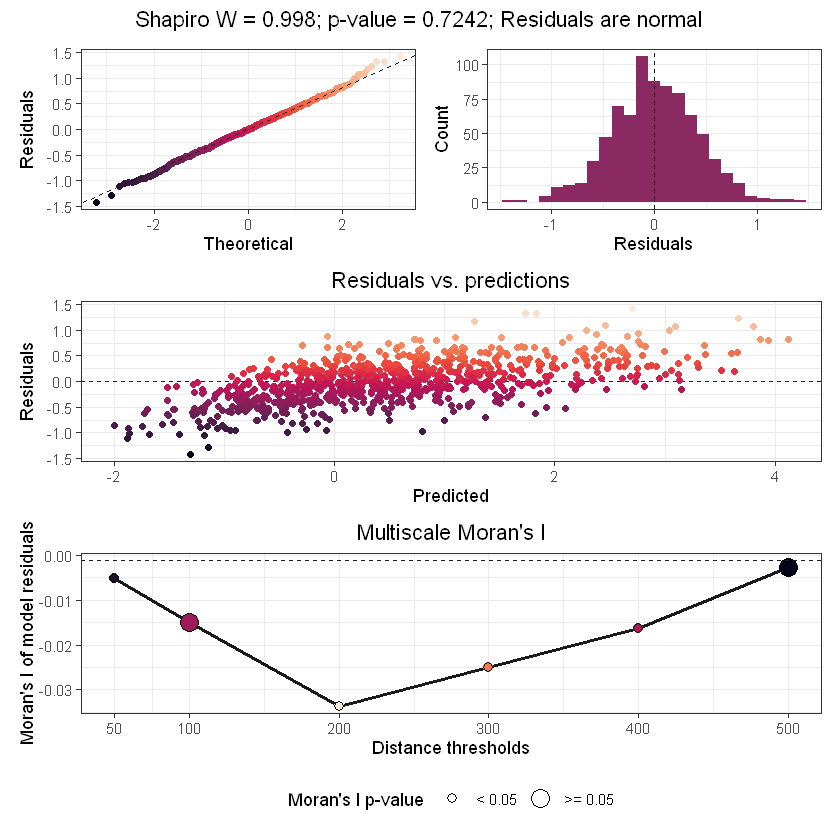

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5101598
  - R squared (cor(obs, pred)^2):     0.9432505
  - Pseudo R squared (cor(obs, pred)):0.9712108
  - RMSE (oob):                       0.9348069
  - RMSE:                             0.4018
  - Normalized RMSE:                  0.2444116

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.29 │  -0.24 │ 

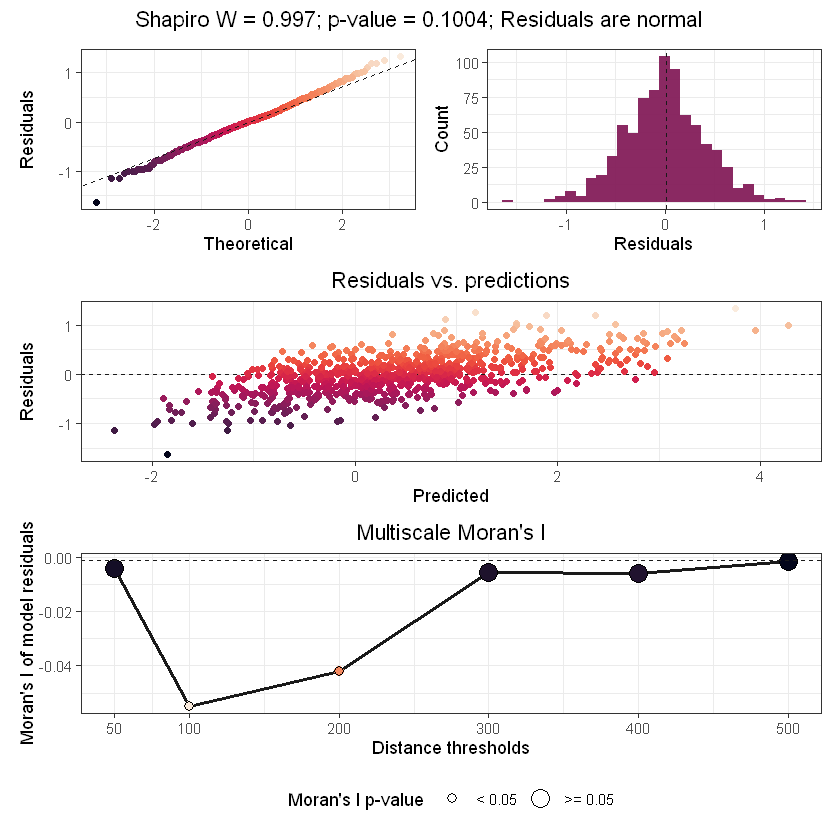

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4910679
  - R squared (cor(obs, pred)^2):     0.943345
  - Pseudo R squared (cor(obs, pred)):0.9712595
  - RMSE (oob):                       1.007616
  - RMSE:                             0.434
  - Normalized RMSE:                  0.2351541

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.62 │  -0.28 │  -0.

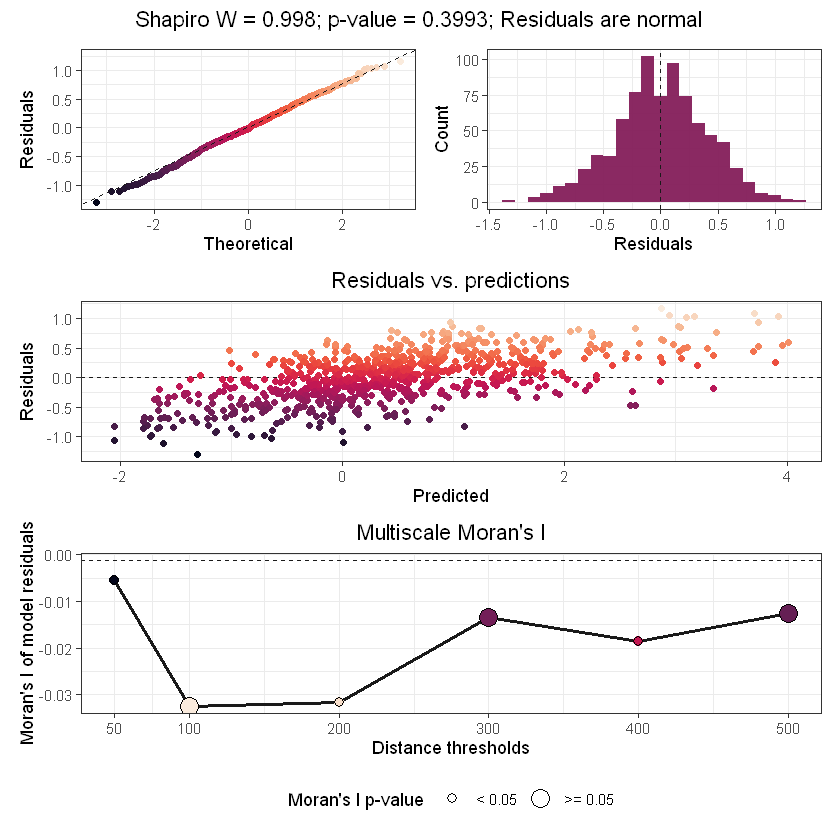

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5214826
  - R squared (cor(obs, pred)^2):     0.942495
  - Pseudo R squared (cor(obs, pred)):0.9708218
  - RMSE (oob):                       0.9721603
  - RMSE:                             0.4215
  - Normalized RMSE:                  0.2374181

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.34 │  -0.27 │  

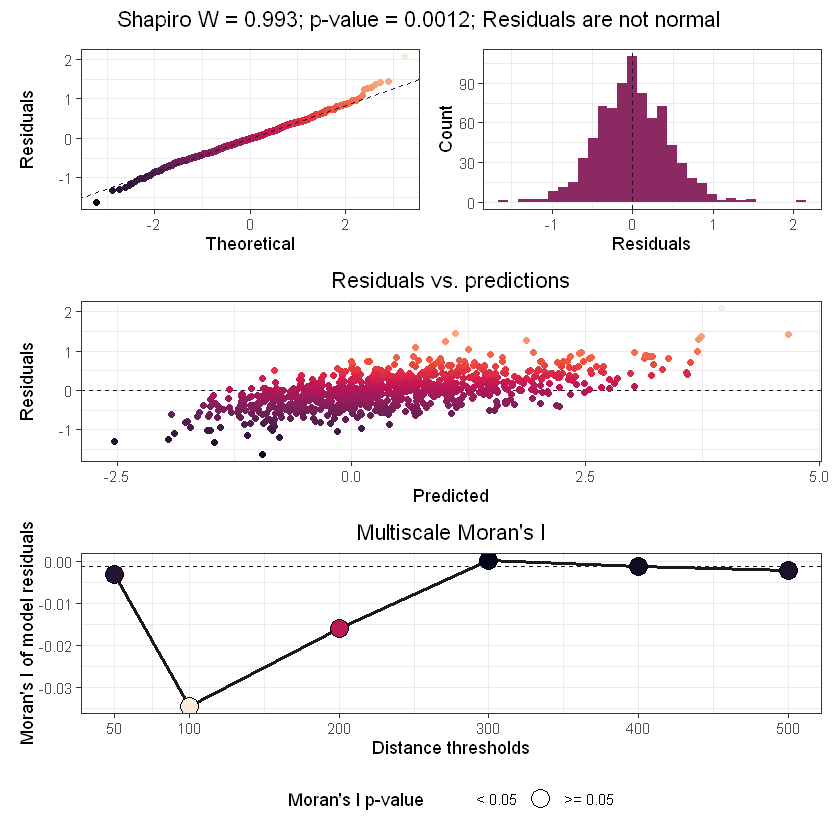

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            10
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5452412
  - R squared (cor(obs, pred)^2):     0.9465243
  - Pseudo R squared (cor(obs, pred)):0.9728948
  - RMSE (oob):                       0.9513912
  - RMSE:                             0.4124
  - Normalized RMSE:                  0.2382622

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.34 │  -0.26 │ 

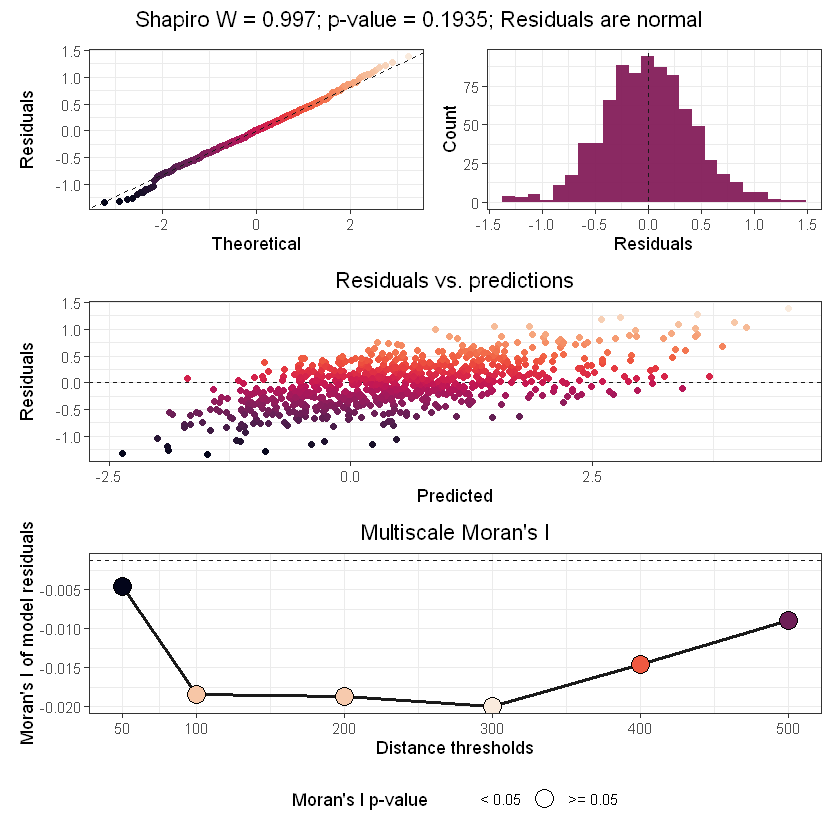

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            10
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5260677
  - R squared (cor(obs, pred)^2):     0.942224
  - Pseudo R squared (cor(obs, pred)):0.9706822
  - RMSE (oob):                       0.9331979
  - RMSE:                             0.4023
  - Normalized RMSE:                  0.2259513

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.41 │  -0.25 │  

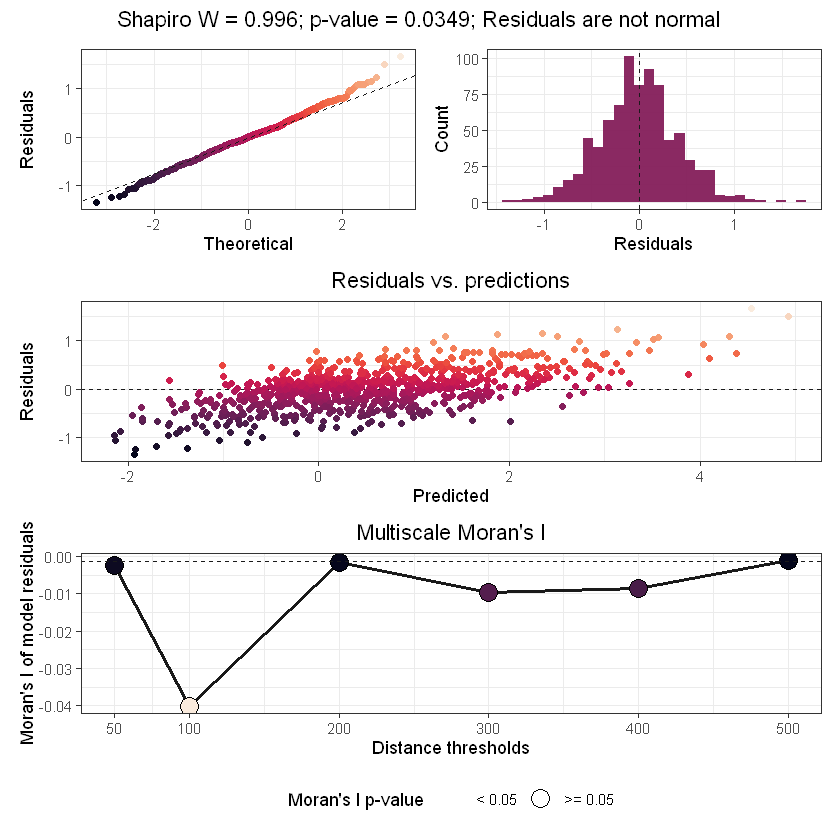

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4952913
  - R squared (cor(obs, pred)^2):     0.9424857
  - Pseudo R squared (cor(obs, pred)):0.970817
  - RMSE (oob):                       0.9188673
  - RMSE:                             0.3987
  - Normalized RMSE:                  0.2396074

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.63 │  -0.25 │   

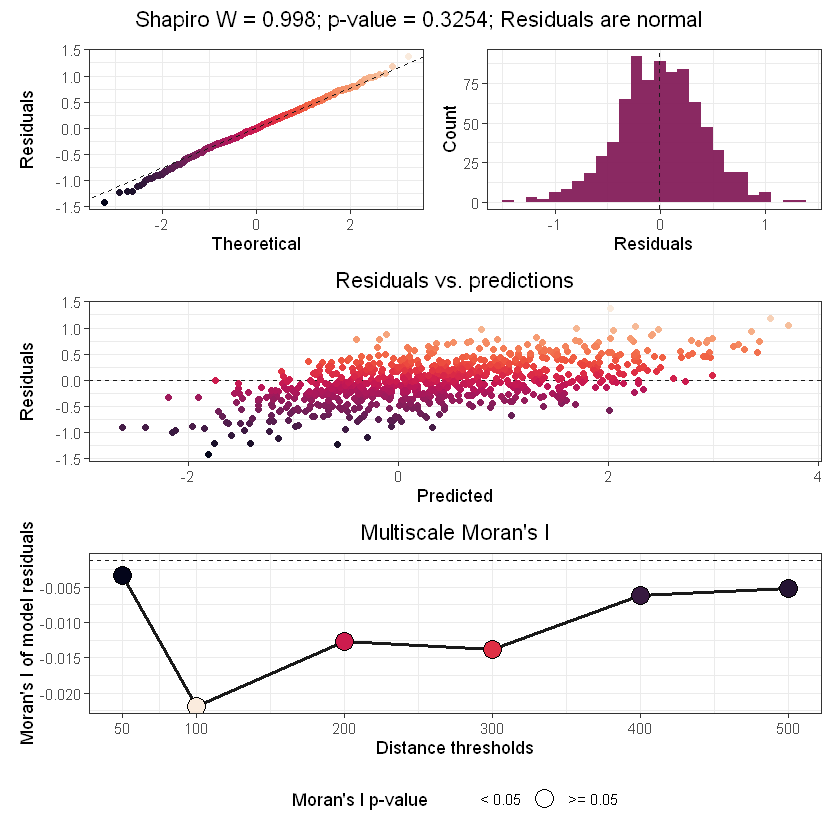

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5094765
  - R squared (cor(obs, pred)^2):     0.9432038
  - Pseudo R squared (cor(obs, pred)):0.9711868
  - RMSE (oob):                       0.9036917
  - RMSE:                             0.3928
  - Normalized RMSE:                  0.2479424

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.16 │  -0.24 │ 

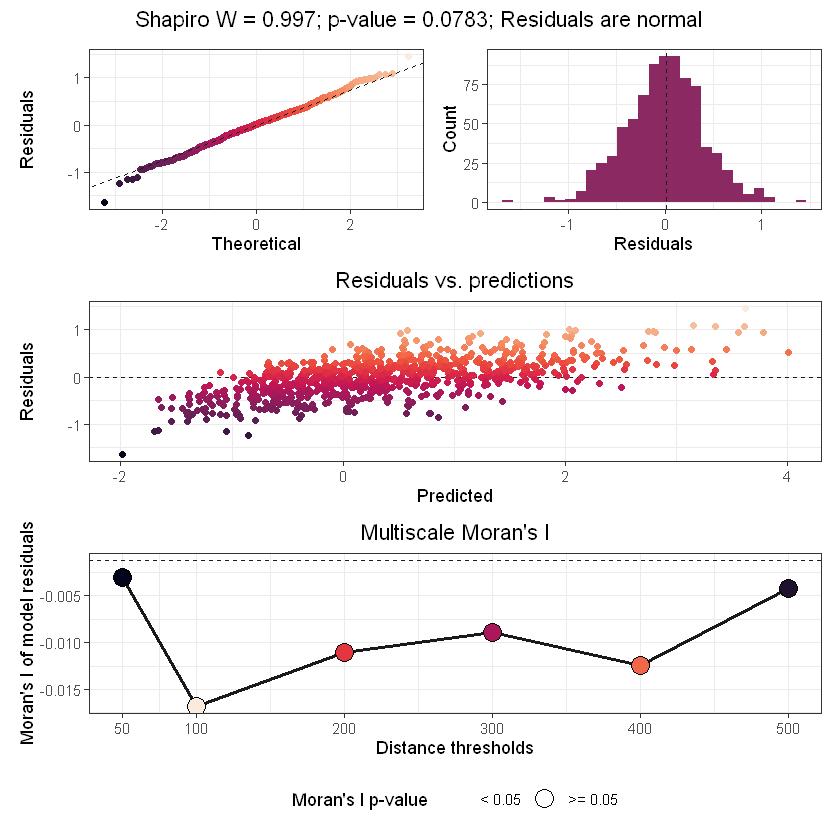

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5235808
  - R squared (cor(obs, pred)^2):     0.9432913
  - Pseudo R squared (cor(obs, pred)):0.9712318
  - RMSE (oob):                       0.9460368
  - RMSE:                             0.4085
  - Normalized RMSE:                  0.2355887

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.12 │  -0.27 │  

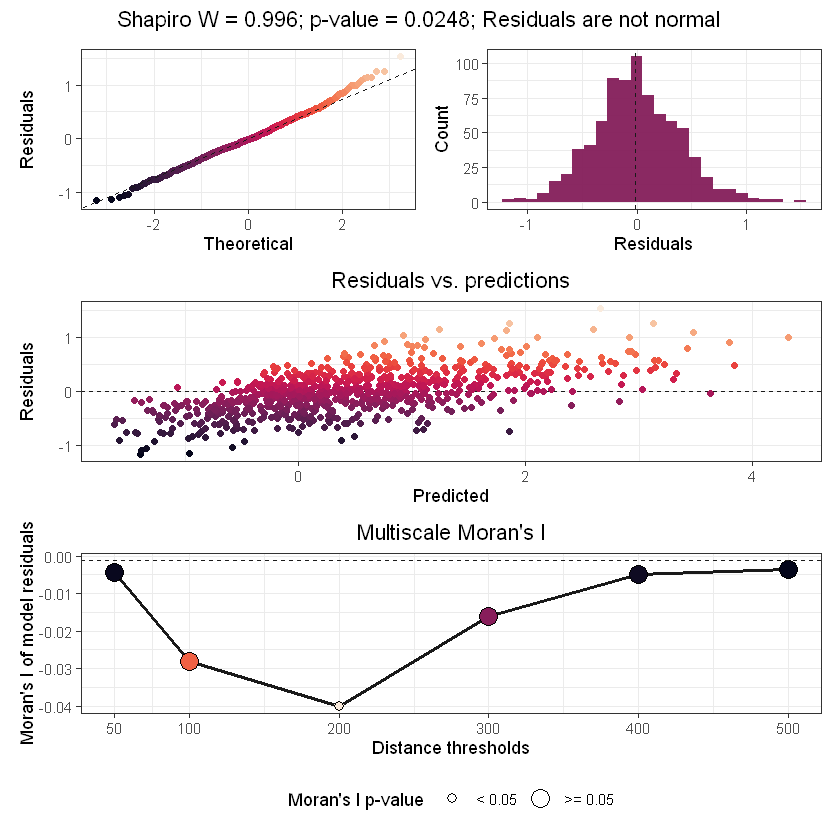

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5165337
  - R squared (cor(obs, pred)^2):     0.9422424
  - Pseudo R squared (cor(obs, pred)):0.9706917
  - RMSE (oob):                       0.9577346
  - RMSE:                             0.4145
  - Normalized RMSE:                  0.2372854

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.58 │  -0.27 │ 

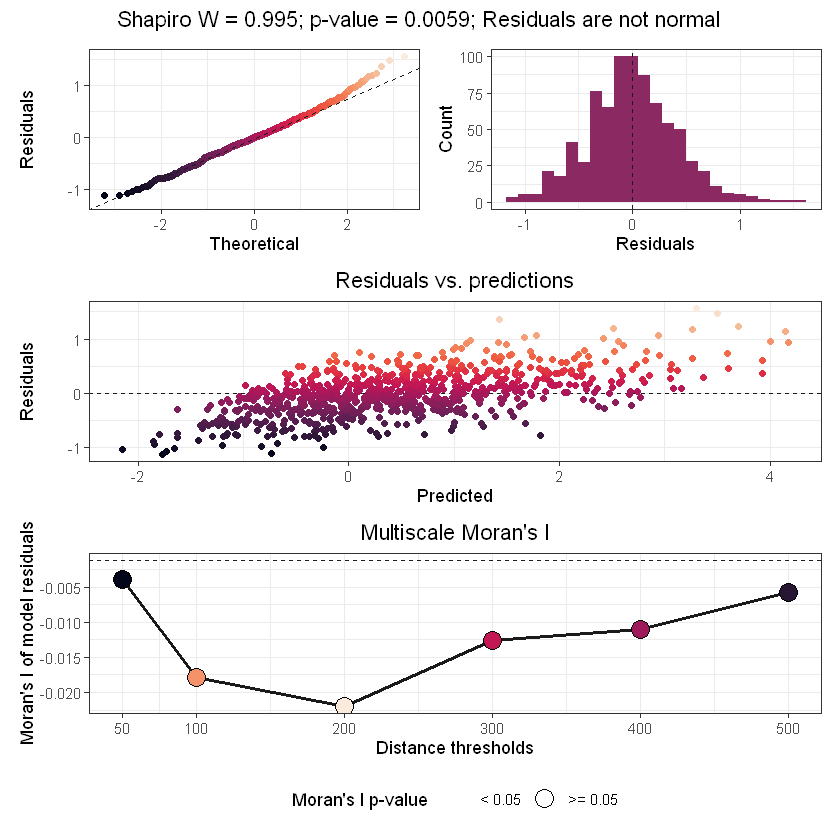

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            18
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5249025
  - R squared (cor(obs, pred)^2):     0.9518292
  - Pseudo R squared (cor(obs, pred)):0.9756173
  - RMSE (oob):                       0.9388989
  - RMSE:                             0.4018
  - Normalized RMSE:                  0.2341231

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.68 │  -0.24 │ 

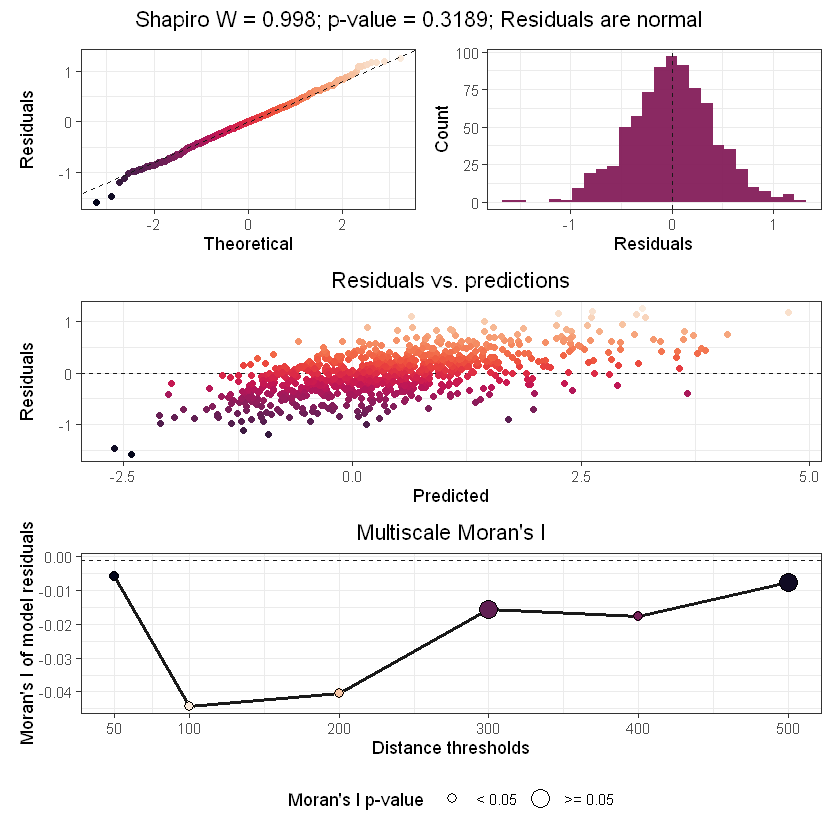

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            13
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5026531
  - R squared (cor(obs, pred)^2):     0.9423232
  - Pseudo R squared (cor(obs, pred)):0.9707333
  - RMSE (oob):                       0.9653997
  - RMSE:                             0.4206
  - Normalized RMSE:                  0.2690434

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.75 │  -0.24 │ 

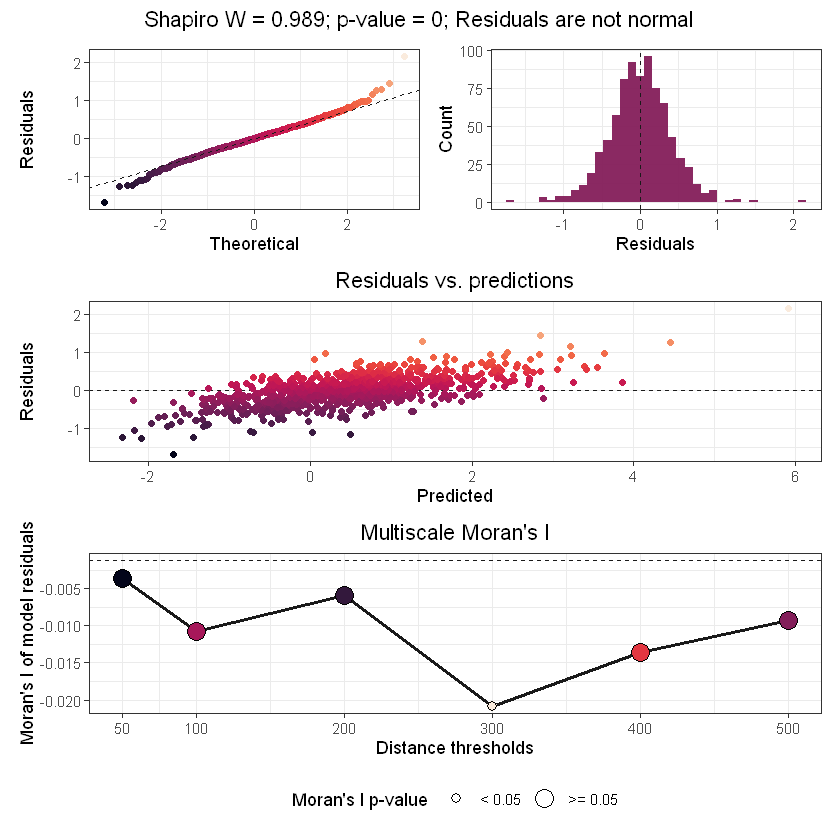

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            12
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5499541
  - R squared (cor(obs, pred)^2):     0.9472319
  - Pseudo R squared (cor(obs, pred)):0.9732584
  - RMSE (oob):                       0.9077784
  - RMSE:                             0.3949
  - Normalized RMSE:                  0.226515

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.22 │  -0.24 │  

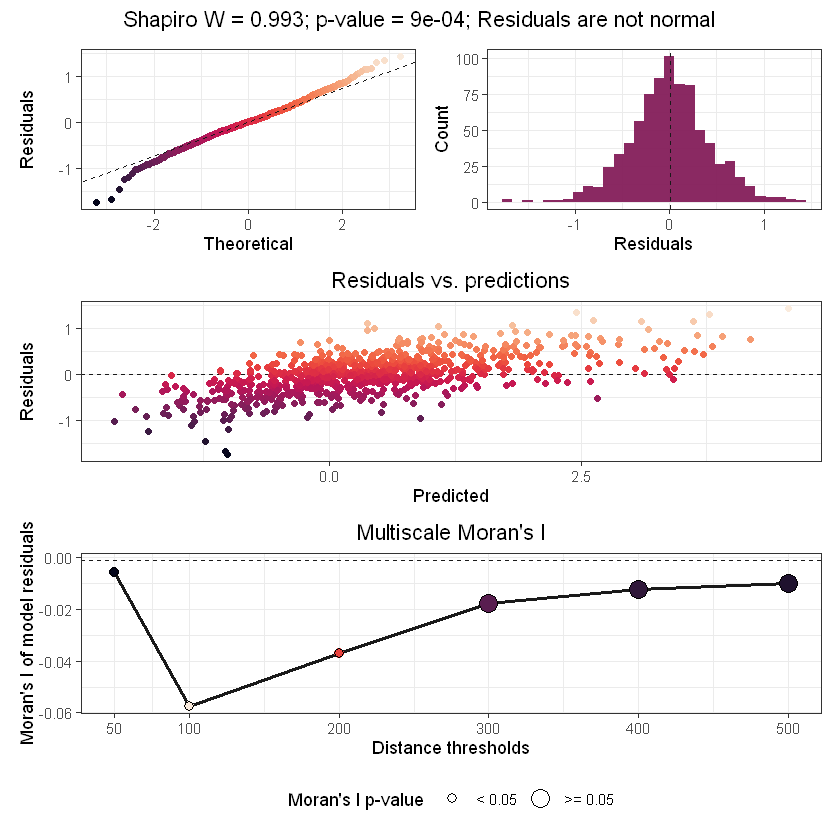

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            13
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.462654
  - R squared (cor(obs, pred)^2):     0.942869
  - Pseudo R squared (cor(obs, pred)):0.9710144
  - RMSE (oob):                       0.9415415
  - RMSE:                             0.4096
  - Normalized RMSE:                  0.2564269

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.38 │  -0.26 │  -

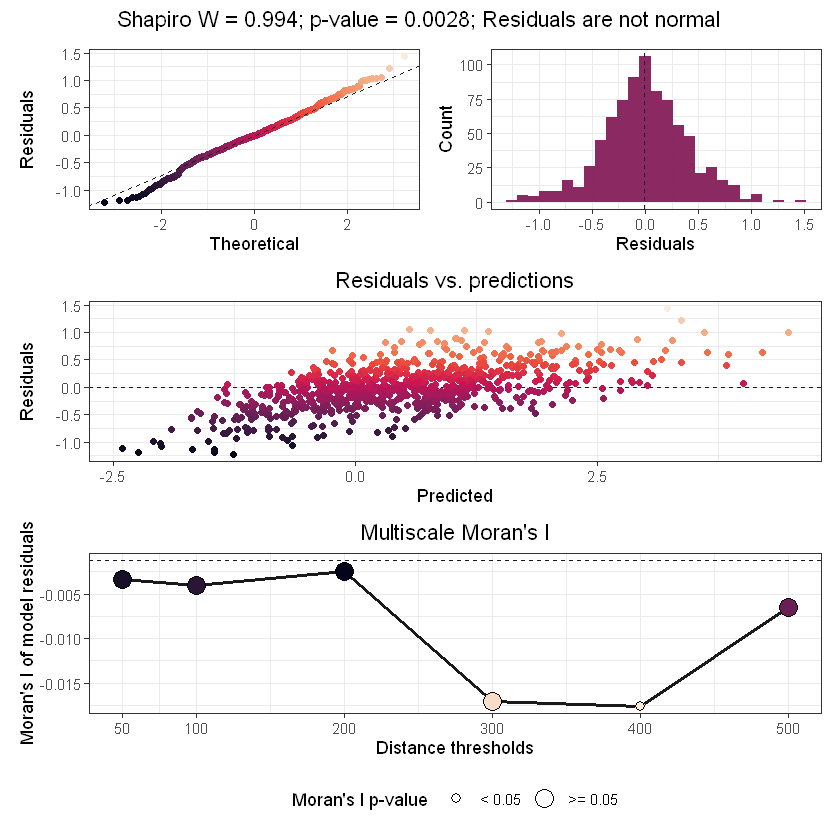

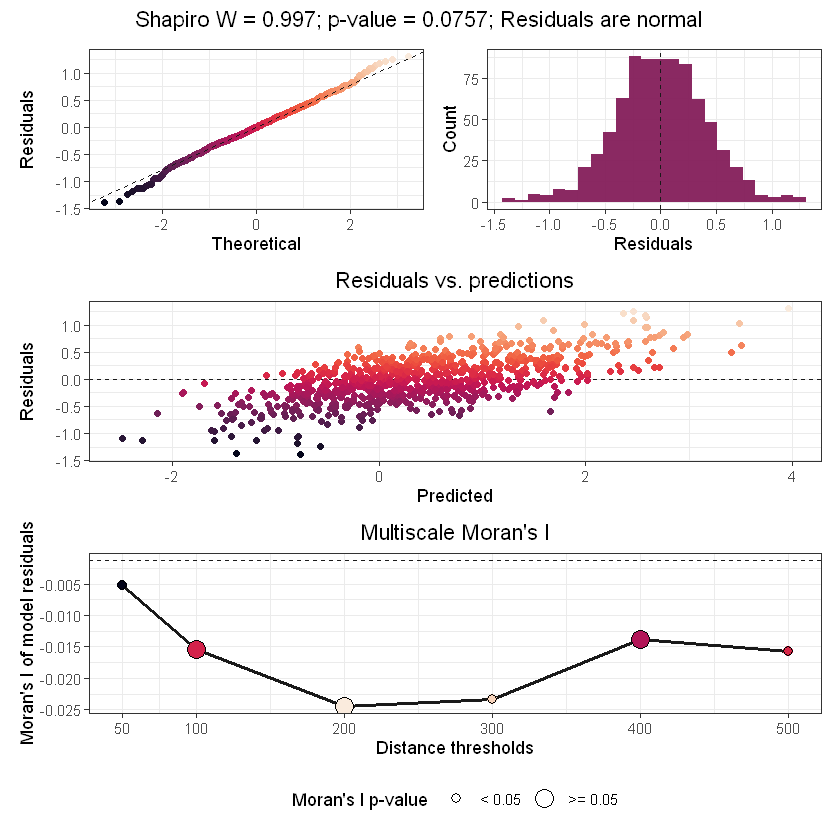

In [10]:
con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

for (layer in list_of_columns) {

  df1 <- dict_geom_sf[[layer]]$df

  model <- spatialRF::rf_spatial(
    data = df1,
    dependent.variable.name = "y",
    predictor.variable.names = c('c1', 'c2'
                  #'t', 'odr_1','odr_2','odr_3','odr_4','odr_5'
                  ),
    distance.matrix = distance_matrix,
    distance.thresholds = c(50, 100, 200, 300, 400, 500)
  )

  spatial_predictors_df <- spatialRF::get_spatial_predictors(model)

  df3 <- cbind(df1, spatial_predictors_df)

  dbWriteTable(
    con,
    paste0(layer, "_sp"),
    df3,
    overwrite = TRUE
  )
}

dbDisconnect(con)

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            17
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5382676
  - R squared (cor(obs, pred)^2):     0.9420326
  - Pseudo R squared (cor(obs, pred)):0.9705836
  - RMSE (oob):                       0.9668107
  - RMSE:                             0.4281
  - Normalized RMSE:                  0.2332028

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.49 │  -0.29 │  

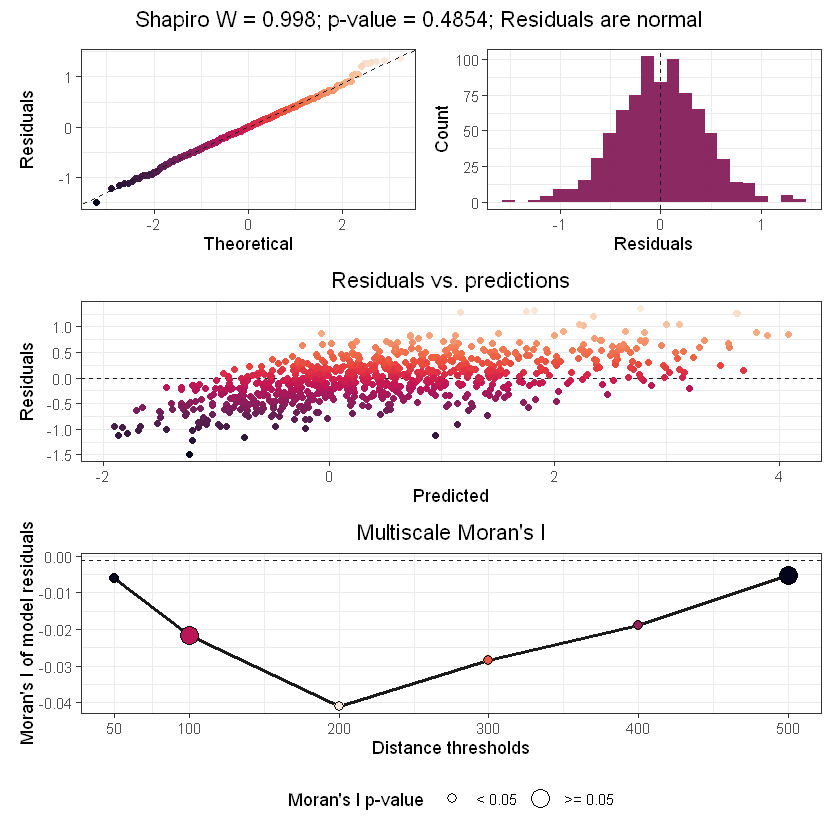

In [13]:
df1 <- dict_geom_sf[['gdf_rho_0_75']]$df

model <- spatialRF::rf_spatial(
    data = df1,
    dependent.variable.name = "y",
    predictor.variable.names = c('c1', 'c2', 't', 'odr_1','odr_2','odr_3','odr_4','odr_5'
                  ),
    distance.matrix = distance_matrix,
    distance.thresholds = c(50, 100, 200, 300, 400, 500)
  )

spatial_predictors_df <- spatialRF::get_spatial_predictors(model)

df3 <- cbind(df1, spatial_predictors_df)


In [15]:
con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

dbWriteTable(
    con,
    paste0("gdf_rho_0_75_sp_t_dr5"),
    df3,
    overwrite = TRUE
  )


dbDisconnect(con)